In [1]:
import numpy as np
import keras
import keras_hub
import tensorflow as tf
import json
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from matplotlib.patches import Rectangle
import random
import math
import torch
import requests

In [2]:
# Quick health check to prove it works:
print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: True
Device Name: Tesla T4


### Utils

In [13]:
color_map = {0: "gray"}


def label_to_color(label):
    if label not in color_map:
        h, s, v = (len(color_map) * 0.618) % 1, 0.5, 0.9
        color_map[label] = hsv_to_rgb((h, s, v))
    return color_map[label]


def draw_box(ax, box, text, color):
    x, y, w, h = box
    ax.add_patch(Rectangle((x, y), w, h, lw=2, ec=color, fc="none"))
    textbox = dict(fc=color, pad=1, ec="none")
    ax.text(x, y, text, c="white", size=10, va="bottom", bbox=textbox)


def draw_image(ax, image):
    ax.set(xlim=(0, 1), ylim=(1, 0), xticks=[], yticks=[], aspect="equal")
    image = plt.imread(image)
    height, width = image.shape[:2]
    hpad = (1 - height / width) / 2 if width > height else 0
    wpad = (1 - width / height) / 2 if height > width else 0
    extent = [wpad, 1 - wpad, 1 - hpad, hpad]
    ax.imshow(image, extent=extent)

### Load Image

In [4]:
url = (
    "https://upload.wikimedia.org/wikipedia/commons/thumb/7/7d/A_Sunday_on_La_Grande_Jatte%2C_Georges_Seurat%2C_1884.jpg/1280px-A_Sunday_on_La_Grande_Jatte%2C_Georges_Seurat%2C_1884.jpg")

local_path = "seurat_painting.jpg"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}
response = requests.get(url, headers=headers)
if response.status_code == 200:
    with open(local_path, "wb") as f:
        f.write(response.content)
else:
    raise Exception(f"Failed to fetch image. Status code: {response.status_code}")
img_loaded = keras.utils.load_img(local_path)
image = np.array([keras.utils.img_to_array(img_loaded)])
print("Image shape:", image.shape)

Image shape: (1, 852, 1280, 3)


In [5]:
image[0].shape

(852, 1280, 3)

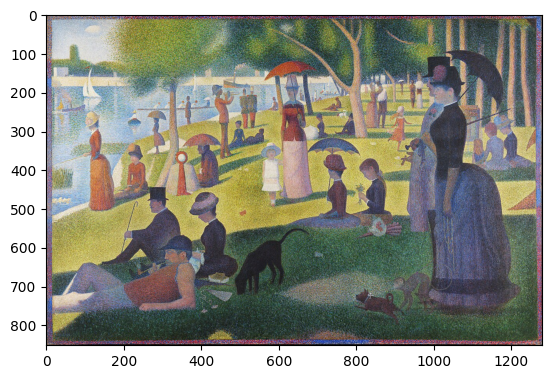

In [17]:
plt.imshow(image[0]/255, cmap="viridis_r")

### Load Model

In [7]:
detector = keras_hub.models.ObjectDetector.from_preset("retinanet_resnet50_fpn_v2_coco", bounding_box_format="rel_xywh",)



100%|██████████| 1.59k/1.59k [00:00<00:00, 1.35MB/s]


100%|██████████| 8.54k/8.54k [00:00<00:00, 20.0MB/s]


100%|██████████| 146M/146M [00:03<00:00, 48.0MB/s]


100%|██████████| 121M/121M [00:02<00:00, 47.3MB/s]


In [8]:
detector.summary()

Preprocessor: "retina_net_object_detector_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ retina_net_image_converter (RetinaNetImageConverter)          │                   Image size: (800, 800) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "retina_net_object_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)           │ (None, None, None, 3)     │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ retina_net_backbone           │ [(None, None, None, 256), │      31,558,592 │ images[0][0]               │
│ (RetinaNetBackbone)           │ (None, None, None, 256),  │                 │                            │
│                               │ (None, None, None, 256),  │                 │                            │
│                               │ (None, None, None, 256),  │                 │                            │
│                               │ (None, None, None, 256)]  │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ box_head (PredictionHead)     │ (None, None, None, 36)    │       2,444,324 │ retina_net_backbone[0][0], │
│                               │                           │                 │ retina_net_backbone[0][1], │
│                               │                           │                 │ retina_net_backbone[0][2], │
│                               │                           │                 │ retina_net_backbone[0][3], │
│                               │                           │                 │ retina_net_backbone[0][4]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classification_head           │ (None, None, None, 819)   │       4,249,139 │ retina_net_backbone[0][0], │
│ (PredictionHead)              │                           │                 │ retina_net_backbone[0][1], │
│                               │                           │                 │ retina_net_backbone[0][2], │
│                               │                           │                 │ retina_net_backbone[0][3], │
│                               │                           │                 │ retina_net_backbone[0][4]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ box_pred_P3 (Reshape)         │ (None, None, 4)           │               0 │ box_head[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ box_pred_P4 (Reshape)         │ (None, None, 4)           │               0 │ box_head[1][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ box_pred_P5 (Reshape)         │ (None, None, 4)           │               0 │ box_head[2][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ box_pred_P6 (Reshape)         │ (None, None, 4)           │               0 │ box_head[3][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ box_pred_P7 (Reshape)         │ (None, None, 4)           │               0 │ box_head[4][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cls_pred_P3 (Reshape)         │ (None, None, 91)          │               0 │ classification_head[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cls_pred_P4 (Reshape)         │ (None, None, 91)          │               0 │ classification_head[1][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 38,252,055 (145.92 MB)

 Trainable params: 38,198,935 (145.72 MB)

 Non-trainable params: 53,120 (207.50 KB)

### Inference Model

In [9]:
predictions = detector.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


In [10]:
[(k, v.shape) for k, v in predictions.items()]

[('boxes', (1, 100, 4)),
 ('confidence', (1, 100)),
 ('labels', (1, 100)),
 ('num_detections', (1,))]

In [11]:
predictions["boxes"][0][0]

array([0.02752607, 0.60643774, 0.28109217, 0.16602355], dtype=float32)

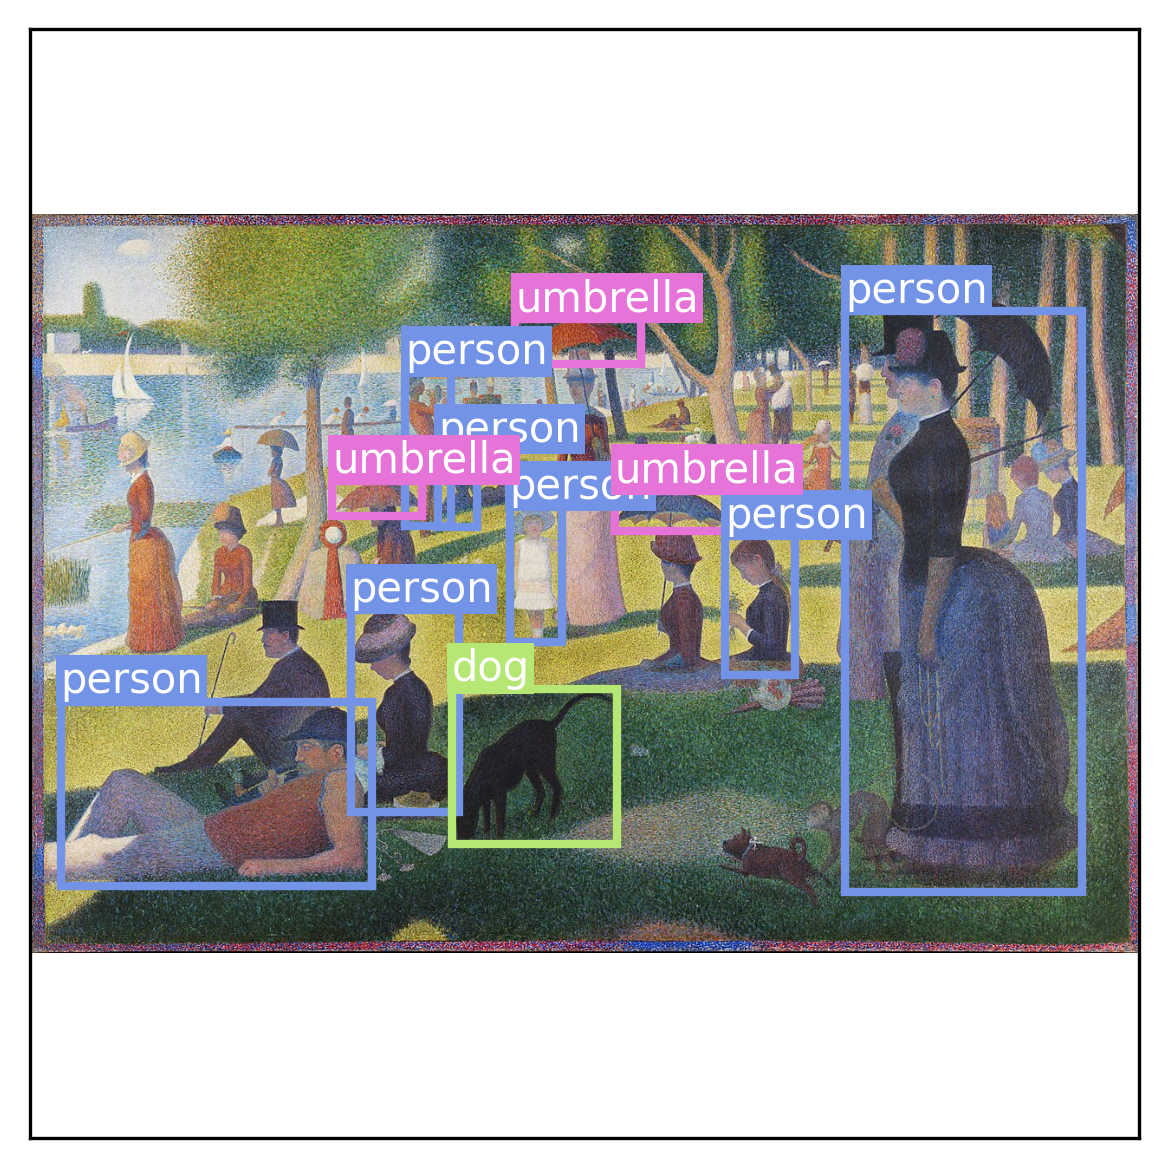

In [16]:
fig, ax = plt.subplots(dpi=300)
draw_image(ax, local_path)
num_detections = predictions["num_detections"][0]
for i in range(num_detections):
    box = predictions["boxes"][0][i]
    label = predictions["labels"][0][i]
    label_name = keras_hub.utils.coco_id_to_name(label)
    draw_box(ax, box, label_name, label_to_color(label))
plt.show()